# 0. Подготовка данных к профилированию

In [63]:
# Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных. Оставляем оригинальный df, работать будем с его копией.
df_orig = pd.read_csv('data.csv')
df = df_orig.copy()

In [64]:
# Смотрим на первые строки датасета, проверяем названия столбцов и структуру

df.head()

,first_name,last_name,age,email,salary,join_date
0,Quincy,White,33,beatrice@example.com,64642,2022-08-07 00:00:00
1,Xena,Rodriguez,28,quincy@example.com,96273,2021-09-03 00:00:00
2,Leo,Smith,56,charlie@example.com,117527,2023-07-07 00:00:00
3,Jack,Allen,33,vera@example.com,54033,2021-12-02 00:00:00
4,Charlie,Taylor,38,quinn@example.com,30837,2023-12-05 00:00:00


In [65]:
# Смотрим на типы данных, чтобы понять, какие столбцы числовые, а какие категориальные.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   first_name  1000 non-null   object
 1   last_name   1000 non-null   object
 2   age         978 non-null    object
 3   email       999 non-null    object
 4   salary      988 non-null    object
 5   join_date   1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB


In [66]:
# Проверяем дубликаты строк в датасете

df.duplicated().sum()

np.int64(0)

На данном этапе можем увидеть, что все столбцы в датафрейме имеют тип "object".
Нужно привести в корректный формат столбцы с числовыми типами данных (salary, age). Также конвертировать тип столбца "join_date" в дату.

# 1. Очистка данных

## 1.1. Cтолбец 'age'

Посмотрим, какие уникальные значения есть в столбце age

In [67]:
df.age.unique()

array(['33', '28', '56', '38', '55', 'unknown', '19', '37', '50', '43',
       '40', '21', '51', '24', '27', '54', '30', '49', '31', '47', '63',
       '26', '42', '32', '34', '44', nan, '52', '23', '57', '45', '53',
       '41', '20', '60', '58', '39', '46', '59', '29', '48', '64', '25',
       '18', '22', '61', '62', '36', '35', '-10', '999'], dtype=object)

Видно, что в столбце есть значения, которые не являются числами. Кроме того, есть отрицательное значение и 999.
Пробуем привести все данные в числовой формат. Там, где не получилось - конвертируем в NaN

In [68]:
df.age = pd.to_numeric(df.age, errors = 'coerce')

Находим выбросы через IQR и заменяем их на null

In [69]:
Q1 = df.age.quantile(0.25)
Q3 = df.age.quantile(0.75)
IQR = Q3 - Q1

df.loc[((df.age < (Q1 - IQR * 1.5)) | (df.age > (Q3 + IQR * 1.5))), 'age'] = None

Посчитаем, сколько всего получилось None, чтобы принять решение о замене их на среднее значение возраста.

In [70]:
df.age.isna().sum()

np.int64(53)

In [71]:
df.age.count()

np.int64(947)

Количетсво None - 53. Всего строк - 1000. 
Так как количество None меньше 10%, замена None на среднее значение это не сильно исказит данные.

In [72]:
clean_mean = int(round(df.age.mean())) # Находим средний возраст без выбросов и null, округляем до целого числа.

df[df.age.isna()] = clean_mean # Заменяем None средним значением


In [73]:
df.age.unique() # Проверяем

array([33., 28., 56., 38., 55., 41., 19., 37., 50., 43., 40., 21., 51.,
       24., 27., 54., 30., 49., 31., 47., 63., 26., 42., 32., 34., 44.,
       52., 23., 57., 45., 53., 20., 60., 58., 39., 46., 59., 29., 48.,
       64., 25., 18., 22., 61., 62., 36., 35.])

## 1.2. Столбец 'first_name'

Так как у нас датасет не очень большой, можно проверить значения через метод unique()

In [74]:
df.first_name.unique() # Проверяем

array(['Quincy', 'Xena', 'Leo', 'Jack', 'Charlie', 41, 'Uma', 'Catherine',
       'Tara', 'Beatrice', 'Eve', 'Wendy', 'Kevin', 'Paul', 'Mia',
       'Isaac', 'Ulysses', 'David', 'Bob', 'Ella', 'Ivy', 'Liam',
       'Walter', 'Hannah', 'Xander', 'Quinn', 'Zoe', 'Steve', 'Frank',
       'Maya', 'Henry', 'Felix', 'Nate', 'Alice', 'Victor', 'Vera',
       'Daniel', 'Aaron', 'Noah', 'Kira', 'Tina', 'Olivia', 'Samuel',
       'Julia', 'Yara', 'Rachel', 'Piper', 'Yasmine', 'Gina', 'Rosa',
       'Owen', 'Grace', '11'], dtype=object)

Посмотрим на те имена, которые попадаются редко. Возможно среди них есть некорректные или мусорные

In [75]:
df.first_name.value_counts().tail()

first_name
Yara    11
Eve     11
Maya    11
Nate    10
11       1
Name: count, dtype: int64

Проверим, есть ли слишком длинные или слишком короткие имена, которые могут быть аномальными

In [76]:
df.first_name.str.len().describe() 

count    947.000000
mean       4.843717
std        1.300053
min        2.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        9.000000
Name: first_name, dtype: float64

Проверка на то, есть ли цифры вместо имени

In [77]:
df[df.first_name.str.contains(r'\d', na=False)]

,first_name,last_name,age,email,salary,join_date
658,11,Martin,18.0,bob@example.com,118873,2021-02-06 00:00:00


Из проверок выше видно, что среди имен есть невалидные данные. В одной строке в имении имеется значение "11".
Чтобы не терять остальные данные и строку, заменим данное значение на Null

In [78]:
df.loc[df.first_name.astype(str).str.contains(r'\d', na=False),'first_name'] = None

In [79]:
df.first_name.unique()

array(['Quincy', 'Xena', 'Leo', 'Jack', 'Charlie', None, 'Uma',
       'Catherine', 'Tara', 'Beatrice', 'Eve', 'Wendy', 'Kevin', 'Paul',
       'Mia', 'Isaac', 'Ulysses', 'David', 'Bob', 'Ella', 'Ivy', 'Liam',
       'Walter', 'Hannah', 'Xander', 'Quinn', 'Zoe', 'Steve', 'Frank',
       'Maya', 'Henry', 'Felix', 'Nate', 'Alice', 'Victor', 'Vera',
       'Daniel', 'Aaron', 'Noah', 'Kira', 'Tina', 'Olivia', 'Samuel',
       'Julia', 'Yara', 'Rachel', 'Piper', 'Yasmine', 'Gina', 'Rosa',
       'Owen', 'Grace'], dtype=object)

In [80]:
df.first_name = df.first_name.str.strip() # На всякий случай убираем пробелы

## 1.3. Столбец 'last_name'

Аналогично first_name проверяем столбец

In [81]:
df['last_name'].unique()

array(['White', 'Rodriguez', 'Smith', 'Allen', 'Taylor', 'Miller', 41,
       'Walker', 'Clark', 'King', 'Wright', 'Hall', 'Thomas', 'Torres',
       'Martin', 'Williams', 'Garcia', 'Flores', 'Baker', 'Hill', 'Green',
       'Scott', 'Nguyen', 'Adams', 'Martinez', 'Jones', 'Mitchell',
       'Rivera', 'Davis', 'Thompson', 'Johnson', 'Wilson', 'Moore', 'Lee',
       'Campbell', 'Brown', 'Harris', 'Jackson', 'Robinson', 'Anderson',
       'Young', 'Lewis', 'Nelson'], dtype=object)

Видно, что среди уникальных имен имеется значения "41". Заменим  их на None

In [82]:
df.loc[df.last_name.astype(str).str.contains(r'\d', na=False),'last_name'] = None

In [83]:
df.last_name.unique()

array(['White', 'Rodriguez', 'Smith', 'Allen', 'Taylor', 'Miller', None,
       'Walker', 'Clark', 'King', 'Wright', 'Hall', 'Thomas', 'Torres',
       'Martin', 'Williams', 'Garcia', 'Flores', 'Baker', 'Hill', 'Green',
       'Scott', 'Nguyen', 'Adams', 'Martinez', 'Jones', 'Mitchell',
       'Rivera', 'Davis', 'Thompson', 'Johnson', 'Wilson', 'Moore', 'Lee',
       'Campbell', 'Brown', 'Harris', 'Jackson', 'Robinson', 'Anderson',
       'Young', 'Lewis', 'Nelson'], dtype=object)

In [84]:
df.last_name.value_counts()

last_name
King         31
Hall         31
Davis        30
Rivera       30
Martin       28
Flores       28
Smith        27
Walker       26
Hill         26
Baker        26
Harris       25
Robinson     24
Miller       24
Jackson      24
Torres       24
Scott        24
Moore        23
White        23
Young        23
Lewis        23
Anderson     22
Adams        22
Jones        22
Thomas       22
Thompson     22
Wilson       22
Allen        22
Williams     21
Martinez     21
Rodriguez    20
Mitchell     20
Garcia       19
Wright       19
Campbell     19
Nguyen       18
Green        18
Clark        18
Brown        17
Lee          16
Johnson      16
Taylor       16
Nelson       15
Name: count, dtype: int64

## 1.4. Cтолбец 'email'

Ищем количество email со значениями null

In [85]:
df.email.isna().sum()

np.int64(1)

Находим количество дубликатов

In [86]:
df.email.duplicated().sum()

np.int64(944)

Найдено большое количество дубликатов (945 шт.)
Практически каждый email в столбце дублируется.
Также видим большое количество значений "41" и  "invalid_email"


In [87]:
df.email.value_counts()

email
41                       53
invalid_email            48
noah@example.com         28
zoe@example.com          25
gina@example.com         24
quinn@example.com        23
alice@example.com        23
tina@example.com         22
ulysses@example.com      22
rosa@example.com         22
bob@example.com          22
leo@example.com          21
olivia@example.com       21
yasmine@example.com      20
vera@example.com         20
piper@example.com        20
jack@example.com         19
julia@example.com        19
felix@example.com        19
xander@example.com       19
charlie@example.com      19
rachel@example.com       18
victor@example.com       18
uma@example.com          18
catherine@example.com    18
walter@example.com       18
wendy@example.com        18
liam@example.com         18
maya@example.com         17
daniel@example.com       17
isaac@example.com        17
grace@example.com        17
eve@example.com          17
quincy@example.com       17
paul@example.com         17
nate@example.c

Найдем все неправильно введеные email через регулярное выражение. Заменим их на Null

In [88]:
df.loc[df.email.str.contains(r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$', na=False) == False, 'email'] = None

## 1.5. Столбец 'salary'

Посмотрим количество дублированных значений и то, какие они.

In [89]:
df.salary.value_counts().head()

salary
41               53
not_available    19
9999999          15
117922            2
65663             2
Name: count, dtype: int64

Видно, что в столбце много повторяющихся аномальных значений "41" и "not_available", "9999999"
Пока что заменим все "not_available" на None

In [90]:
df.salary = df.salary.replace('not_available', None)

Приводим все данные в числовой вид и смотрим на описательную статистику столбца.

In [91]:
df.salary = pd.to_numeric(df.salary, errors = 'coerce')
df.salary.describe()

count    9.690000e+02
mean     2.253286e+05
std      1.226707e+06
min     -8.208500e+04
25%      4.955100e+04
50%      7.233800e+04
75%      9.923400e+04
max      9.999999e+06
Name: salary, dtype: float64

Избавляемся от отрицательных значений

In [92]:
df.loc[df.salary < 0, 'salary'] = None
df.salary.describe()

count    9.680000e+02
mean     2.256462e+05
std      1.227301e+06
min      4.100000e+01
25%      4.962675e+04
50%      7.235200e+04
75%      9.930450e+04
max      9.999999e+06
Name: salary, dtype: float64

Избавляемся от выбросов

In [93]:
Q1 = df.salary.quantile(0.25)
Q3 = df.salary.quantile(0.75)
IQR = Q3 - Q1

df.loc[((df.salary < (Q1 - IQR * 1.5)) | (df.salary > (Q3 + IQR * 1.5))), 'salary'] = None

df.salary.describe()

count       953.000000
mean      71800.136411
std       31350.816616
min          41.000000
25%       49194.000000
50%       71807.000000
75%       98665.000000
max      119998.000000
Name: salary, dtype: float64

Видим, что у нас осталось много ошибочных значений "41"

salary
41.0        53
117922.0     2
65663.0      2
113299.0     2
99234.0      2
            ..
66622.0      1
47167.0      1
100953.0     1
78020.0      1
56318.0      1
Name: count, Length: 892, dtype: int64

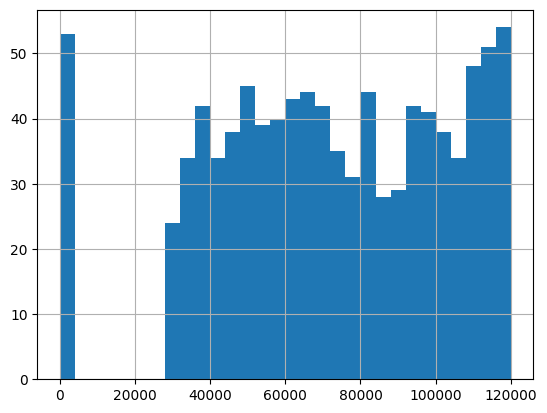

In [94]:
df.salary.hist(bins=30)
df.salary.value_counts()


Заменяем данные значения на None, проверяем данные

In [95]:
df.loc[df.salary < 50, 'salary'] = None
df.salary.describe()

count       900.000000
mean      76025.952222
std       26820.940335
min       30000.000000
25%       52565.500000
50%       74890.500000
75%       99847.750000
max      119998.000000
Name: salary, dtype: float64

Нужно проверить, сколько на данный момент мы имеем значений None в столбце 'salary'. 
Это нужно для принятия решения о замене None на медиану.

In [96]:
df.salary.isna().sum()

np.int64(100)

Видно, что количество None - 100 штук. Это составляет 10% от общего количество строк. Чтобы не исказить данные, лучше не заменять None на медианное значение.

## 1.6. Столбец 'join_date'

Визуально оцениваем дубликаты, ищем аномалии и очень часто повторяющиеся значения.
Видно, что есть повторяющееся аномально много раз число "41" и дата "2022-13-01".
Мы не может точно определить, ошибочные ли значения "2022-13-01", или это просто другой формат даты (2022-01-13). Но так как "2022-13-01" не является валидной датой, то мы можем заменить ее на Null.


In [97]:
df.join_date.value_counts()

join_date
41                     53
2022-13-01             49
2022-04-24 00:00:00     5
2022-07-15 00:00:00     4
2021-06-14 00:00:00     4
                       ..
2021-12-13 00:00:00     1
2022-03-12 00:00:00     1
2023-04-21 00:00:00     1
2022-04-06 00:00:00     1
2022-11-23 00:00:00     1
Name: count, Length: 666, dtype: int64

Переводим все значения в формат даты.

In [98]:
df.join_date = pd.to_datetime(df.join_date, errors='coerce')
df.join_date.isna().sum()

np.int64(102)

Теперь оцениваем сами значения

In [99]:
df.join_date.describe()

count                              898
mean     2021-11-11 13:08:57.193763840
min                1920-01-22 00:00:00
25%                2020-12-21 12:00:00
50%                2021-12-30 12:00:00
75%                2022-12-13 12:00:00
max                2026-05-12 00:00:00
Name: join_date, dtype: object

Видно, что есть аномальное значние в min и в max. Проверим, много ли их в начале и в конце столбца.

In [100]:
df.join_date.sort_values().head()

321   1920-01-22
772   2020-01-01
857   2020-01-02
865   2020-01-04
559   2020-01-08
Name: join_date, dtype: datetime64[ns]

Тут используем метод dropna(), чтобы не учитывать None при сортировке

In [101]:
df.join_date.dropna().sort_values().tail()

471   2023-12-25
74    2023-12-27
628   2023-12-28
105   2023-12-31
296   2026-05-12
Name: join_date, dtype: datetime64[ns]

Видим, что в начале и в конце есть по одному аномальному значению. Заменим их на None.

In [102]:
df.loc[(df.join_date == '1920-01-22') | (df.join_date == '2026-05-12'), 'join_date'] = None

# 2. Базовая аналитика

## 2.1. Общая характеристика dataframe

Смотрим на типы данных в столбцах, размер датафрейма

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   first_name  946 non-null    object        
 1   last_name   947 non-null    object        
 2   age         1000 non-null   float64       
 3   email       896 non-null    object        
 4   salary      900 non-null    float64       
 5   join_date   896 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 47.0+ KB


In [104]:
df.shape # Размер датафрейма явно

(1000, 6)

In [105]:
df.isna().sum() # Точное количество значений Null в каждом столбце

first_name     54
last_name      53
age             0
email         104
salary        100
join_date     104
dtype: int64

## 2.2. Описательная статистика

Выводим информацию по всем стобцам с числовыми значениями и датой

In [106]:
df.describe()

,age,salary,join_date
count,1000.000000,900.000000,896
mean,41.047000,76025.952222,2021-12-21 05:10:10.714285824
min,18.000000,30000.000000,2020-01-01 00:00:00
25%,30.000000,52565.500000,2020-12-22 12:00:00
50%,41.000000,74890.500000,2021-12-30 12:00:00
75%,52.000000,99847.750000,2022-12-12 12:00:00
max,64.000000,119998.000000,2023-12-31 00:00:00
std,13.322247,26820.940335,NaN


In [107]:
df[['first_name', 'last_name', 'email']].describe()

,first_name,last_name,email
count,946,947,896
unique,51,42,51
top,Piper,King,noah@example.com
freq,32,31,28


## 2.3. Распределение возраста сотрудников

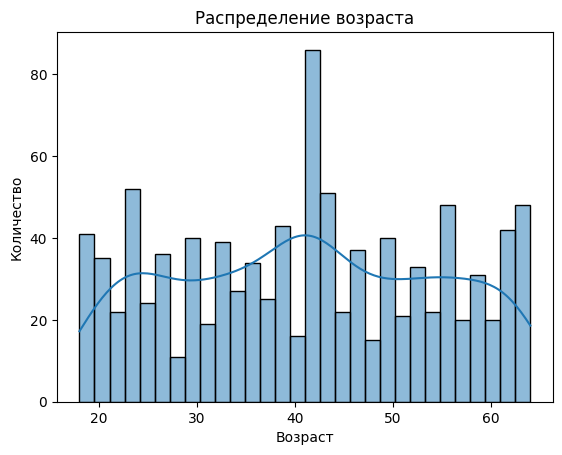

In [108]:
sns.histplot(df.age, bins=30, kde=True)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

## 2.4. Распределение зарплат

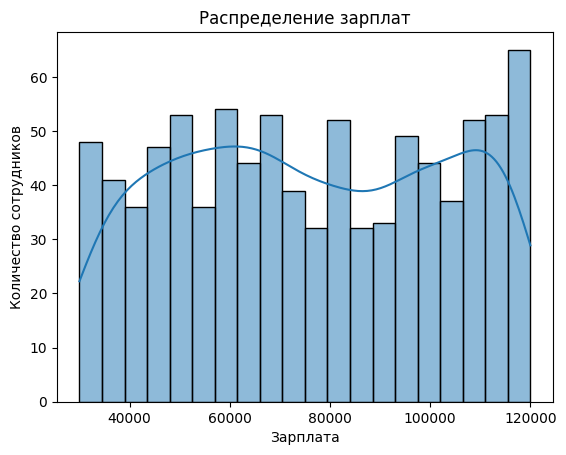

In [109]:
sns.histplot(df.salary, bins=20, kde=True)
plt.title('Распределение зарплат')
plt.xlabel('Зарплата')
plt.ylabel('Количество сотрудников')
plt.show()

## 2.5. Найм по годам

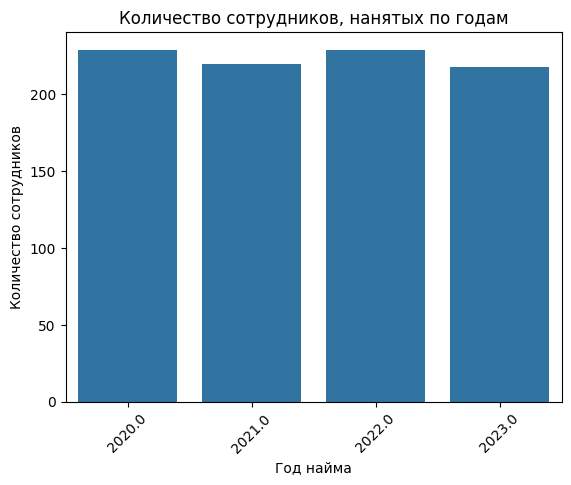

In [110]:
df['join_year'] = df.join_date.dt.year
sns.countplot(x='join_year', data=df)
plt.title('Количество сотрудников, нанятых по годам')
plt.xlabel('Год найма')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()

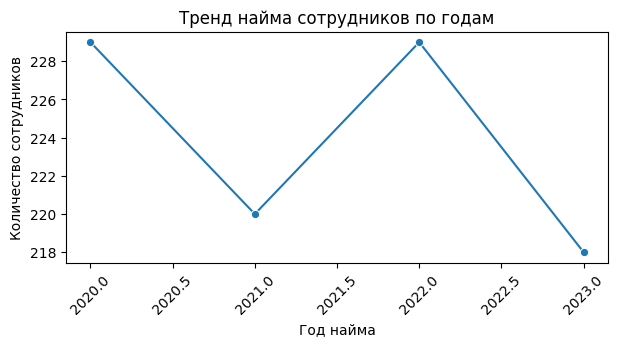

In [111]:
# Анализ временных рядов найма сотрудников по годам
df['join_year'] = df.join_date.dt.year
join_year_counts = df['join_year'].value_counts().sort_index()
plt.figure(figsize=(7, 3))
sns.lineplot(x=join_year_counts.index, y=join_year_counts.values, marker='o')
plt.title('Тренд найма сотрудников по годам')
plt.xlabel('Год найма')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.show()

## 2.6. Boxplot для возраста и зарплаты

<Axes: xlabel='age'>

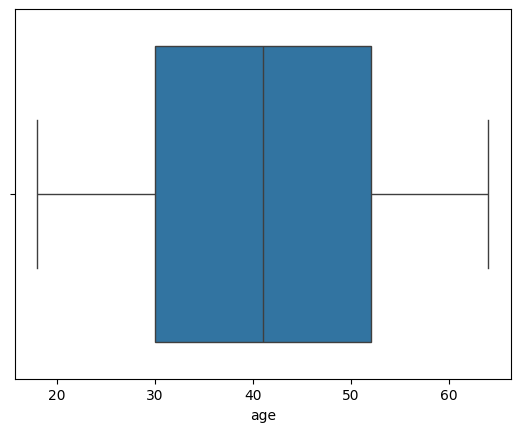

In [112]:
sns.boxplot(x=df.age)

<Axes: xlabel='salary'>

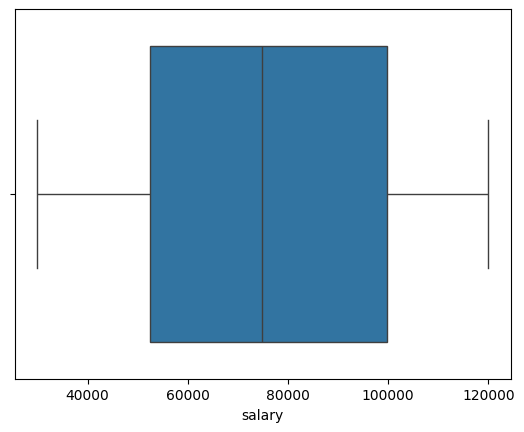

In [113]:
sns.boxplot(x=df.salary)

In [114]:
sns.heatmap()

TypeError: heatmap() missing 1 required positional argument: 'data'

## 2.7. Корреляция между возрастом, зарплатой и годом найма

In [ ]:
corr = df[['age', 'salary', 'join_year']].corr()
corr

,age,salary,join_year
age,1.000000,-0.025638,-0.029598
salary,-0.025638,1.000000,0.011751
join_year,-0.029598,0.011751,1.000000


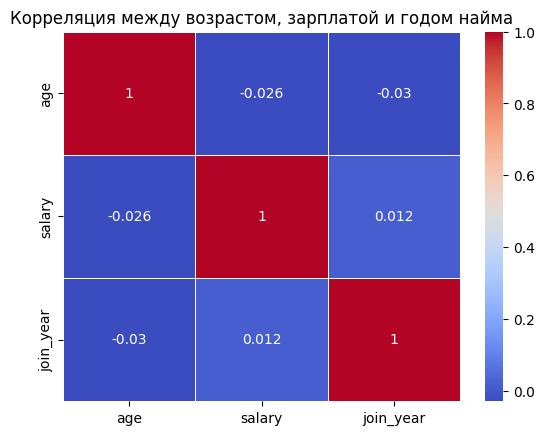

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция между возрастом, зарплатой и годом найма')
plt.show()

## 2.8. Связь между возрастом и зарплатой

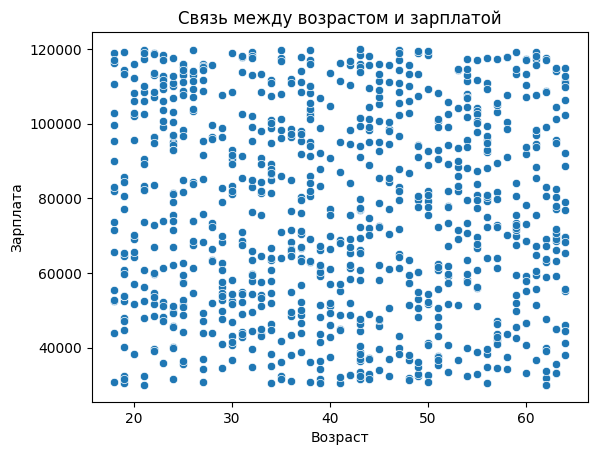

In [ ]:
sns.scatterplot(x='age', y='salary', data=df)
plt.title('Связь между возрастом и зарплатой')
plt.xlabel('Возраст')
plt.ylabel('Зарплата')
plt.show()